In [ ]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook')

CONV_DIR = '../examples/comparisons/closed_boundary_DIIID/convergence_03_20'

K = 10 # number of refinement points

rows = []
for folder in sorted(os.listdir(CONV_DIR)):
    rpath = os.path.join(CONV_DIR, folder, 'results.json')
    if not os.path.isfile(rpath):
        continue
    m = re.match(r'lambda:([^,]+),coils:(\d+)', folder)
    if not m:
        continue
    with open(rpath) as f:
        data = json.load(f)

    lbfgs = data['methods'].get('Multi-start L-BFGS')
    bayes = data['methods'].get('Bayesian')
    if not lbfgs or not bayes or 'n_bayesian_evals' not in bayes:
        continue

    ref_costs = bayes.get('refinement_costs', [])
    ref_evals = bayes.get('refinement_evals', [])
    if len(ref_costs) < K or len(ref_evals) < K:
        continue

    n_bo       = int(bayes['n_bayesian_evals'])
    cost_5r    = float(ref_costs[K - 1])
    evals_5r   = n_bo + int(sum(ref_evals[:K]))

    rows.append({
        'coils':          int(m.group(2)),
        'lambda':         float(m.group(1)),
        'lbfgs_cost':     lbfgs['best_cost'],
        'lbfgs_evals':    lbfgs['n_evals'],
        'lbfgs_starts':   lbfgs['starts_completed'],
        'bayes_5r_cost':  cost_5r,
        'bayes_5r_evals': evals_5r,
        'bf_cost':        data.get('brute_force_cost', float('nan')),
    })

df = pd.DataFrame(rows)
df['lbfgs_calls_per_start'] = df['lbfgs_evals'] / df['lbfgs_starts']
print(f"Loaded {len(df)} configs with >= {K} refinements")

KeyError: 'lbfgs_evals'

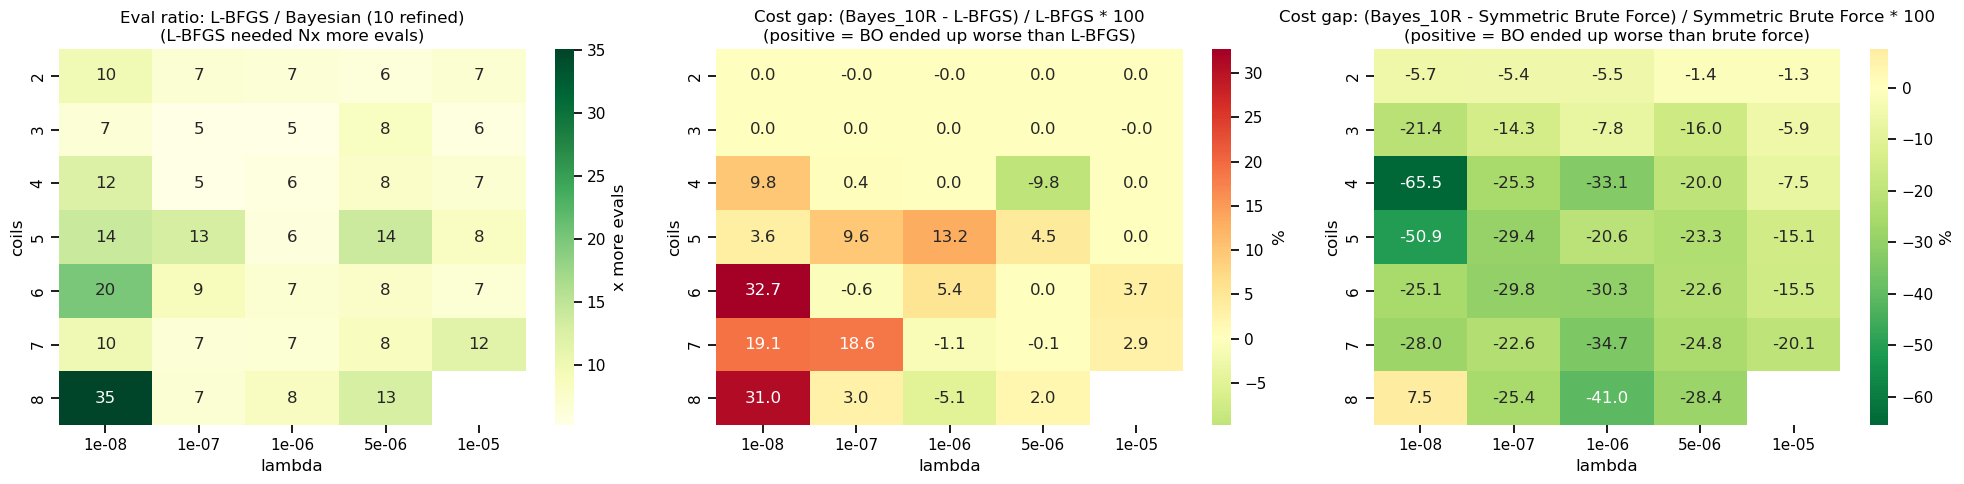

In [ ]:
df['eval_ratio']     = df['lbfgs_evals'] / df['bayes_5r_evals']
df['cost_gap_lbfgs'] = (df['bayes_5r_cost'] - df['lbfgs_cost']) / df['lbfgs_cost'] * 100
df['cost_gap_bf']    = (df['bayes_5r_cost'] - df['bf_cost'])    / df['bf_cost']    * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- left: eval ratio ---
pivot_evals = df.pivot_table(index='coils', columns='lambda', values='eval_ratio')
pivot_evals = pivot_evals.reindex(sorted(pivot_evals.columns), axis=1)
sns.heatmap(
    pivot_evals, annot=True, fmt='.0f', cmap='YlGn',
    ax=axes[0],
    cbar_kws={'label': 'x more evals'}
)
axes[0].set_title(f"Eval ratio: L-BFGS / Bayesian ({K} refined)\n(L-BFGS needed Nx more evals)")
axes[0].set_xlabel('lambda')
axes[0].set_ylabel('coils')

# --- middle: cost gap vs L-BFGS ---
pivot_lbfgs = df.pivot_table(index='coils', columns='lambda', values='cost_gap_lbfgs')
pivot_lbfgs = pivot_lbfgs.reindex(sorted(pivot_lbfgs.columns), axis=1)
sns.heatmap(
    pivot_lbfgs, annot=True, fmt='.1f', cmap='RdYlGn_r',
    ax=axes[1], center=0,
    cbar_kws={'label': '%'}
)
axes[1].set_title(f"Cost gap: (Bayes_{K}R - L-BFGS) / L-BFGS * 100\n(positive = BO ended up worse than L-BFGS)")
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('coils')

# --- right: cost gap vs brute force ---
pivot_bf = df.pivot_table(index='coils', columns='lambda', values='cost_gap_bf')
pivot_bf = pivot_bf.reindex(sorted(pivot_bf.columns), axis=1)
sns.heatmap(
    pivot_bf, annot=True, fmt='.1f', cmap='RdYlGn_r',
    ax=axes[2], center=0,
    cbar_kws={'label': '%'}
)
axes[2].set_title(f"Cost gap: (Bayes_{K}R - Symmetric Brute Force) / Symmetric Brute Force * 100\n(positive = BO ended up worse than brute force)")
axes[2].set_xlabel('lambda')
axes[2].set_ylabel('coils')

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Run structure table (refinement capped at K=5 points)
# ------------------------------------------------------------------
struct_rows = []
for folder in sorted(os.listdir(CONV_DIR)):
    rpath = os.path.join(CONV_DIR, folder, 'results.json')
    if not os.path.isfile(rpath):
        continue
    m = re.match(r'lambda:([^,]+),coils:(\d+)', folder)
    if not m:
        continue
    with open(rpath) as f:
        data = json.load(f)

    lbfgs = data['methods'].get('Multi-start L-BFGS')
    bayes = data['methods'].get('Bayesian')
    if not lbfgs or not bayes:
        continue

    n_initial      = int(bayes.get('n_initial', float('nan')))
    n_bayesian     = int(bayes['n_bayesian_evals'])
    n_gp_guided    = n_bayesian - n_initial
    ref_evals      = bayes.get('refinement_evals', [])
    refinement_total = int(sum(ref_evals[:K])) if ref_evals else 0

    struct_rows.append({
        'coils':                    int(m.group(2)),
        'lambda':                   float(m.group(1)),
        'bayes_total_evals':        n_bayesian + refinement_total,
        'bayes_n_initial':          n_initial,
        'bayes_gp_guided':          n_gp_guided,
        'bayes_pts_refined':        min(int(bayes.get('pts_refined', 0)), K),
        'bayes_refinement_evals':   refinement_total,
        'lbfgs_total_evals':        int(lbfgs['n_evals']),
        'lbfgs_starts':             int(lbfgs['starts_completed']),
        'lbfgs_evals_per_start':    lbfgs['n_evals'] / lbfgs['starts_completed'],
    })

struct_df = pd.DataFrame(struct_rows).sort_values(['coils', 'lambda'])

display(struct_df.style
    .format({
        'lambda':                 '{:.2e}',
        'bayes_total_evals':      '{:,}',
        'bayes_n_initial':        '{:,}',
        'bayes_gp_guided':        '{:,}',
        'bayes_pts_refined':      '{:,}',
        'bayes_refinement_evals': '{:,}',
        'lbfgs_total_evals':      '{:,}',
        'lbfgs_starts':           '{:,}',
        'lbfgs_evals_per_start':  '{:.0f}',
    })
    .set_caption(f'Run structure: Bayesian (capped at {K} refinements) vs L-BFGS')
)

,coils,lambda,bayes_total_evals,bayes_n_initial,bayes_gp_guided,bayes_pts_refined,bayes_refinement_evals,lbfgs_total_evals,lbfgs_starts,lbfgs_evals_per_start
20,2,1.00e-08,"1,338",71,112,10,"1,155","13,025",52,250
13,2,1.00e-07,"1,534",71,223,10,"1,240","10,660",51,209
6,2,1.00e-06,"1,214",71,78,10,"1,065","7,960",51,156
27,2,5.00e-06,"1,002",71,76,10,855,"6,240",51,122
0,2,1.00e-05,941,71,55,10,815,"6,615",53,125
21,3,1.00e-08,"4,202",130,61,10,"4,011","27,741",52,533
14,3,1.00e-07,"4,221",130,101,10,"3,990","22,414",52,431
7,3,1.00e-06,"3,156",130,51,10,"2,975","16,422",52,316
28,3,5.00e-06,"2,023",130,80,10,"1,813","16,660",60,278
1,3,1.00e-05,"2,457",130,108,10,"2,219","13,944",53,263


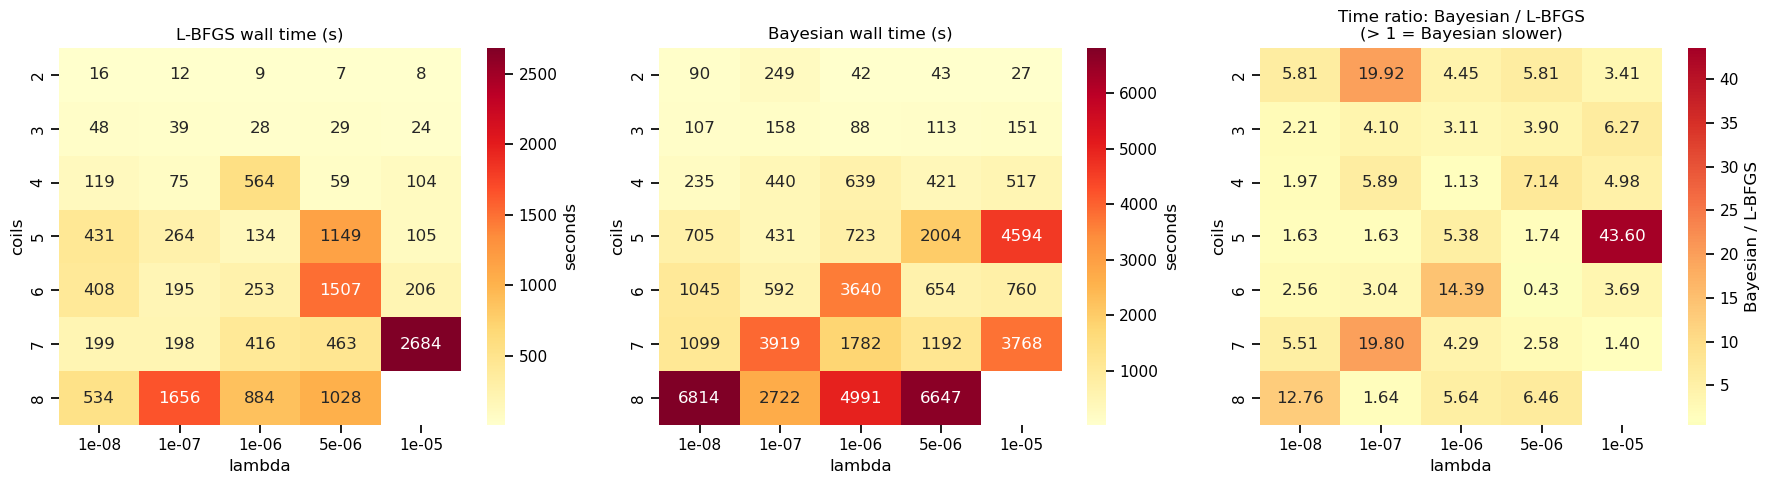

,coils,lambda,lbfgs_time,bayesian_time,time_ratio
20,2,1.00e-08,15.5s,90.0s,5.81
13,2,1.00e-07,12.5s,248.6s,19.92
6,2,1.00e-06,9.4s,41.8s,4.45
27,2,5.00e-06,7.4s,43.0s,5.81
0,2,1.00e-05,7.8s,26.8s,3.41
21,3,1.00e-08,48.1s,106.5s,2.21
14,3,1.00e-07,38.6s,158.2s,4.10
7,3,1.00e-06,28.2s,87.9s,3.11
28,3,5.00e-06,29.0s,112.9s,3.90
1,3,1.00e-05,24.1s,151.2s,6.27


In [ ]:
# ------------------------------------------------------------------
# Wall-clock time by lambda and coils
# ------------------------------------------------------------------
time_rows = []
for folder in sorted(os.listdir(CONV_DIR)):
    rpath = os.path.join(CONV_DIR, folder, 'results.json')
    if not os.path.isfile(rpath):
        continue
    m = re.match(r'lambda:([^,]+),coils:(\d+)', folder)
    if not m:
        continue
    with open(rpath) as f:
        data = json.load(f)

    lbfgs = data['methods'].get('Multi-start L-BFGS')
    bayes = data['methods'].get('Bayesian')
    if not lbfgs or not bayes:
        continue

    time_rows.append({
        'coils':        int(m.group(2)),
        'lambda':       float(m.group(1)),
        'lbfgs_time':   float(lbfgs['time']),
        'bayesian_time': float(bayes['time']),
    })

time_df = pd.DataFrame(time_rows)
time_df['time_ratio'] = time_df['bayesian_time'] / time_df['lbfgs_time']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in [
    (axes[0], 'lbfgs_time',    'L-BFGS wall time (s)'),
    (axes[1], 'bayesian_time', 'Bayesian wall time (s)'),
]:
    pivot = time_df.pivot_table(index='coils', columns='lambda', values=col)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'seconds'})
    ax.set_title(title)
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

pivot_ratio = time_df.pivot_table(index='coils', columns='lambda', values='time_ratio')
pivot_ratio = pivot_ratio.reindex(sorted(pivot_ratio.columns), axis=1)
sns.heatmap(pivot_ratio, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[2], center=1.0,
            cbar_kws={'label': 'Bayesian / L-BFGS'})
axes[2].set_title('Time ratio: Bayesian / L-BFGS\n(> 1 = Bayesian slower)')
axes[2].set_xlabel('lambda')
axes[2].set_ylabel('coils')

plt.tight_layout()
plt.show()

display(time_df.sort_values(['coils', 'lambda']).style.format({
    'lambda':        '{:.2e}',
    'lbfgs_time':    '{:.1f}s',
    'bayesian_time': '{:.1f}s',
    'time_ratio':    '{:.2f}',
}))